# Figures & Results
### Uncertainty-Aware Histopathology Survival Analysis

Central notebook for the figures and results used in the presentation and the
future paper, organized into five sections:

1. **Setup** - imports, paths, and the pooled-prediction loader.
2. **Background & Methods** - the slide-to-features preprocessing pipeline.
3. **Training Curves** - convergence of every training run.
4. **Discrimination & Calibration** - how good the *predictions* are.
5. **Uncertainty Evaluation** - how good the *uncertainty* is.

Figures are saved under `results/figures/publication_figures/`.

# 1. Setup

Imports, cohort/results paths, and the pooled out-of-fold prediction loader
(reconstructs each row's fold and normalizes within fold before pooling).

In [1]:
import ast
import json
import sys
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
from lifelines.utils import concordance_index as ll_cindex
from scipy.stats import spearmanr
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict

plt.style.use('default')
plt.rc("figure", dpi=150)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.eval.metrics import concordance_index

In [2]:
# Cohort paths
COHORT = "TCGA_GBMLGG"

# Data paths
SURVIVAL_TABLE_PATH = PROJECT_ROOT / "data" / "interim" / f"survival_table_{COHORT}.csv"
SPLITS_TABLE_PATH = PROJECT_ROOT / "data" / "processed" / "experiments" / f"uni_v2_{COHORT}" / "splits.csv"
SURVIVAL_METADATA_PATH = PROJECT_ROOT / "data" / "processed" / "experiments" / f"uni_v2_{COHORT}" / "survival_metadata.csv"

# TRIDENT paths
TRIDENT_WORK = PROJECT_ROOT / "data" / "processed" / "trident" / COHORT / "work"
THUMBNAILS_DIR = TRIDENT_WORK / "thumbnails"
CONTOURS_DIR = TRIDENT_WORK / "contours"
PATCHES_DIR = TRIDENT_WORK / "patches"
GEOJSON_DIR = PROJECT_ROOT / "data" / "processed" / "trident" / COHORT / "geojson"

# Tuning logs paths
ARCH_TUNE_LOGS_PATH = PROJECT_ROOT / "logs" / "abmil_survrnc_arch_119448.out"
LOSS_TUNE_LOGS_PATH = PROJECT_ROOT / "logs" / "abmil_survrnc_loss_119450.out"

# Training logs paths
MC_DROP_TRAIN_LOGS_PATH = PROJECT_ROOT / "logs" / "abmil_mcdropout_119485.out"
ENSEMBLE_TRAIN_LOGS_PATH = PROJECT_ROOT / "logs" / "abmil_ensemble_119486.out"
SNGP_TRAIN_LOGS_PATH = PROJECT_ROOT / "logs" / "abmil_sngp_119487.out"

# Results
RESULTS_DIR = PROJECT_ROOT / "results"

# MC-dropout paths
MC_DROP_DATA_ROOT = RESULTS_DIR / "mc_dropout_abmil_cox_tcga_gbmlgg"
MC_DROP_CONFIG_PATH = MC_DROP_DATA_ROOT / "config.json"
MC_DROP_CV_TRIALS_PATH = MC_DROP_DATA_ROOT / "cv_trials.csv"
MC_DROP_CV_SUMMARY_PATH = MC_DROP_DATA_ROOT / "cv_summary.csv"
MC_DROP_CV_POOLED_PRED_PATH = MC_DROP_DATA_ROOT / "cv_pooled_predictions.csv"
MC_DROP_TEST_SUMMARY_PATH = MC_DROP_DATA_ROOT / "test_summary.csv"
MC_DROP_TEST_PRED_PATH = MC_DROP_DATA_ROOT / "test_predictions.csv"
MC_DROP_LEARNING_CURVES_PATH = MC_DROP_DATA_ROOT / "learning_curves.csv"
MC_DROP_HISTORIES_PATH = MC_DROP_DATA_ROOT / "histories.json"
MC_DROP_CHECKPOINTS_DIR = MC_DROP_DATA_ROOT / "checkpoints"
MC_DROP_FROZEN_CKPT_PATH = MC_DROP_CHECKPOINTS_DIR / "frozen_split.pt"

# Deep ensemble paths
ENSEMBLE_DATA_ROOT = RESULTS_DIR / "deep_ensembles_abmil_cox_tcga_gbmlgg"
ENSEMBLE_CONFIG_PATH = ENSEMBLE_DATA_ROOT / "config.json"
ENSEMBLE_CV_TRIALS_PATH = ENSEMBLE_DATA_ROOT / "cv_trials.csv"
ENSEMBLE_CV_SUMMARY_PATH = ENSEMBLE_DATA_ROOT / "cv_summary.csv"
ENSEMBLE_CV_POOLED_PRED_PATH = ENSEMBLE_DATA_ROOT / "cv_pooled_predictions.csv"
ENSEMBLE_TEST_SUMMARY_PATH = ENSEMBLE_DATA_ROOT / "test_summary.csv"
ENSEMBLE_TEST_PRED_PATH = ENSEMBLE_DATA_ROOT / "test_predictions.csv"
ENSEMBLE_LEARNING_CURVES_PATH = ENSEMBLE_DATA_ROOT / "learning_curves.csv"
ENSEMBLE_HISTORIES_PATH = ENSEMBLE_DATA_ROOT / "histories.json"
ENSEMBLE_CHECKPOINTS_DIR = ENSEMBLE_DATA_ROOT / "checkpoints"

# SNGP paths
SNGP_DATA_ROOT = RESULTS_DIR / "sngp_abmil_cox_tcga_gbmlgg"
SNGP_CONFIG_PATH = SNGP_DATA_ROOT / "config.json"
SNGP_CV_TRIALS_PATH = SNGP_DATA_ROOT / "cv_trials.csv"
SNGP_CV_SUMMARY_PATH = SNGP_DATA_ROOT / "cv_summary.csv"
SNGP_CV_POOLED_PRED_PATH = SNGP_DATA_ROOT / "cv_pooled_predictions.csv"
SNGP_TEST_SUMMARY_PATH = SNGP_DATA_ROOT / "test_summary.csv"
SNGP_TEST_PRED_PATH = SNGP_DATA_ROOT / "test_predictions.csv"
SNGP_LEARNING_CURVES_PATH = SNGP_DATA_ROOT / "learning_curves.csv"
SNGP_HISTORIES_PATH = SNGP_DATA_ROOT / "histories.json"
SNGP_CHECKPOINTS_DIR = SNGP_DATA_ROOT / "checkpoints"
SNGP_FROZEN_CKPT_PATH = SNGP_CHECKPOINTS_DIR / "frozen_split.pt"

UQ_ROOTS = {
    "MC-dropout":     MC_DROP_DATA_ROOT,
    "Deep ensembles": ENSEMBLE_DATA_ROOT,
    "SNGP":           SNGP_DATA_ROOT,
}

# Figure output paths
FIGURES_DIR = PROJECT_ROOT / "results" / "figures" / "publication_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Pooled out-of-fold predictions: recover fold identity, put folds on one scale
#
# The five CV folds are five separately-fit models, and a Cox head's risk score has
# no absolute scale -- each model's scores are only meaningful up to a shift and a
# stretch. cv_pooled_predictions.csv concatenates the five held-out frames raw, so
# pooling them mixes five incompatible scales. That distorts the pooled C-index and
# the Breslow calibration, and -- because risk_std is pooled the same way -- it makes
# "rank patients by uncertainty" partly "rank patients by which fold scored them".
#
# The existing cv_pooled_predictions.csv files have no `fold` column (the training
# scripts now write one, but re-running them is expensive). run_cross_validation()
# appends the held-out frames fold by fold, so fold identity is recoverable from row
# order plus cv_trials.n_patients. add_fold() reconstructs it and then *verifies* the
# reconstruction by checking each block reproduces that fold's recorded c_index -- if
# the row-order assumption were ever wrong, this raises instead of silently misleading.
Z_BY_FOLD = True   # put risk_mean / risk_std on a common within-fold scale before pooling


def slug(name):
    """Filesystem-safe figure name (no spaces -- these paths end up in LaTeX)."""
    return name.lower().replace(" ", "_").replace("-", "_")


def add_fold(pooled, trials):
    """Attach the fold each pooled row came from; raise if it fails to reproduce cv_trials."""
    trials = trials.sort_values("fold")
    pooled = pooled.copy()

    if "fold" not in pooled.columns:      # reconstruct from row order (see note above)
        if int(trials["n_patients"].sum()) != len(pooled):
            raise ValueError("pooled row count != sum of fold sizes; row-order assumption is broken")
        pooled["fold"] = np.repeat(trials["fold"].to_numpy(), trials["n_patients"].to_numpy())

    for fold, row in trials.set_index("fold").iterrows():
        block = pooled[pooled["fold"] == fold]
        recomputed = concordance_index(block.risk_mean, block.time, block.event)
        if not np.isclose(recomputed, row["c_index"], atol=1e-9):
            raise ValueError(
                f"fold {fold}: reconstructed C-index {recomputed:.6f} != "
                f"cv_trials {row['c_index']:.6f}; reconstruction is invalid"
            )
    return pooled


def load_pooled(root, z=None):
    """Pooled out-of-fold predictions with a verified `fold` column, put on a common scale.

    risk_mean is z-scored within fold: its *scale* carries meaning (the Breslow baseline
    exponentiates it), so we keep an interval scale and only strip the per-model shift
    and stretch.

    risk_std becomes a within-fold percentile rank, because every use of it here is a
    ranking ("drop the least confident") and only its order matters. Z-scoring is not
    enough -- it equalises each fold's mean and spread but not the *shape* of its tail.
    MC-dropout's fold 3 has a risk_std skew of 6.1 (vs 1.5-2.3 for the other folds), so
    even after z-scoring its most-confident patient sits at -0.65 while other folds reach
    -1.1, and not one fold-3 patient survives into the confident 20%. A percentile rank
    makes the retained set fold-balanced by construction (verified in the confound cell).
    """
    pooled = add_fold(
        pd.read_csv(root / "cv_pooled_predictions.csv"),
        pd.read_csv(root / "cv_trials.csv"),
    )
    if Z_BY_FOLD if z is None else z:
        pooled["risk_mean"] = pooled.groupby("fold").risk_mean.transform(
            lambda s: (s - s.mean()) / s.std())
        pooled["risk_std"] = pooled.groupby("fold").risk_std.rank(pct=True)
    return pooled


def pooled_cindex_ci(df, n_boot=1000, seed=0):
    """Pooled C-index + bootstrap percentile CI (cv_summary.csv's is computed on raw scales)."""
    rng = np.random.default_rng(seed)
    time, risk, event = df.time.to_numpy(), df.risk_mean.to_numpy(), df.event.to_numpy()
    boot = []
    for _ in range(n_boot):
        i = rng.integers(0, len(df), len(df))
        if event[i].sum() == 0:
            continue
        try:
            boot.append(ll_cindex(time[i], -risk[i], event[i]))
        except ZeroDivisionError:
            pass
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return ll_cindex(time, -risk, event), lo, hi


POOLED = {m: load_pooled(r) for m, r in UQ_ROOTS.items()
          if (r / "cv_pooled_predictions.csv").exists()}

print(f"Fold reconstruction verified against cv_trials for: {', '.join(POOLED)}")
print(f"Z_BY_FOLD = {Z_BY_FOLD}  (risk_mean: z-score within fold; risk_std: within-fold percentile)\n")
print("Per-fold scales on the RAW pooled scores (why this matters):")
for m, r in UQ_ROOTS.items():
    raw = load_pooled(r, z=False)
    risk = raw.groupby("fold").risk_mean.agg(["mean", "std"])
    unc = raw.groupby("fold").risk_std.agg(["mean", "skew"])
    print(f"\t{m:16s} risk: fold mean {risk['mean'].min():+.2f} to {risk['mean'].max():+.2f},"
          f"fold sd {risk['std'].min():.2f} to {risk['std'].max():.2f}\t|\t"
          f"unc: fold skew {unc['skew'].min():.1f} to {unc['skew'].max():.1f}")

Fold reconstruction verified against cv_trials for: MC-dropout, Deep ensembles, SNGP
Z_BY_FOLD = True  (risk_mean: z-score within fold; risk_std: within-fold percentile)

Per-fold scales on the RAW pooled scores (why this matters):
	MC-dropout       risk: fold mean -1.43 to -0.73,fold sd 1.05 to 1.74	|	unc: fold skew 1.5 to 6.1
	Deep ensembles   risk: fold mean -1.02 to -0.42,fold sd 1.13 to 1.64	|	unc: fold skew 0.1 to 0.7
	SNGP             risk: fold mean -0.10 to -0.02,fold sd 0.06 to 0.26	|	unc: fold skew 0.0 to 0.8


---
# 2. Background & Methods

One representative slide through the Trident preprocessing pipeline that turns each
whole-slide image into UNI-v2 patch features for the ABMIL + Cox survival model.

## WSI $\rightarrow$ Segmentation $\rightarrow$ Patching

One representative TCGA-GBMLGG slide shown at three stages of the Trident
preprocessing pipeline, from the **already-computed** outputs: the raw
whole-slide thumbnail, the tissue-vs-background segmentation contour, and the
patch grid fed to the **UNI-v2** encoder ($20\times$, $256\times256$ px). The
patch grid is drawn from the saved coordinates.


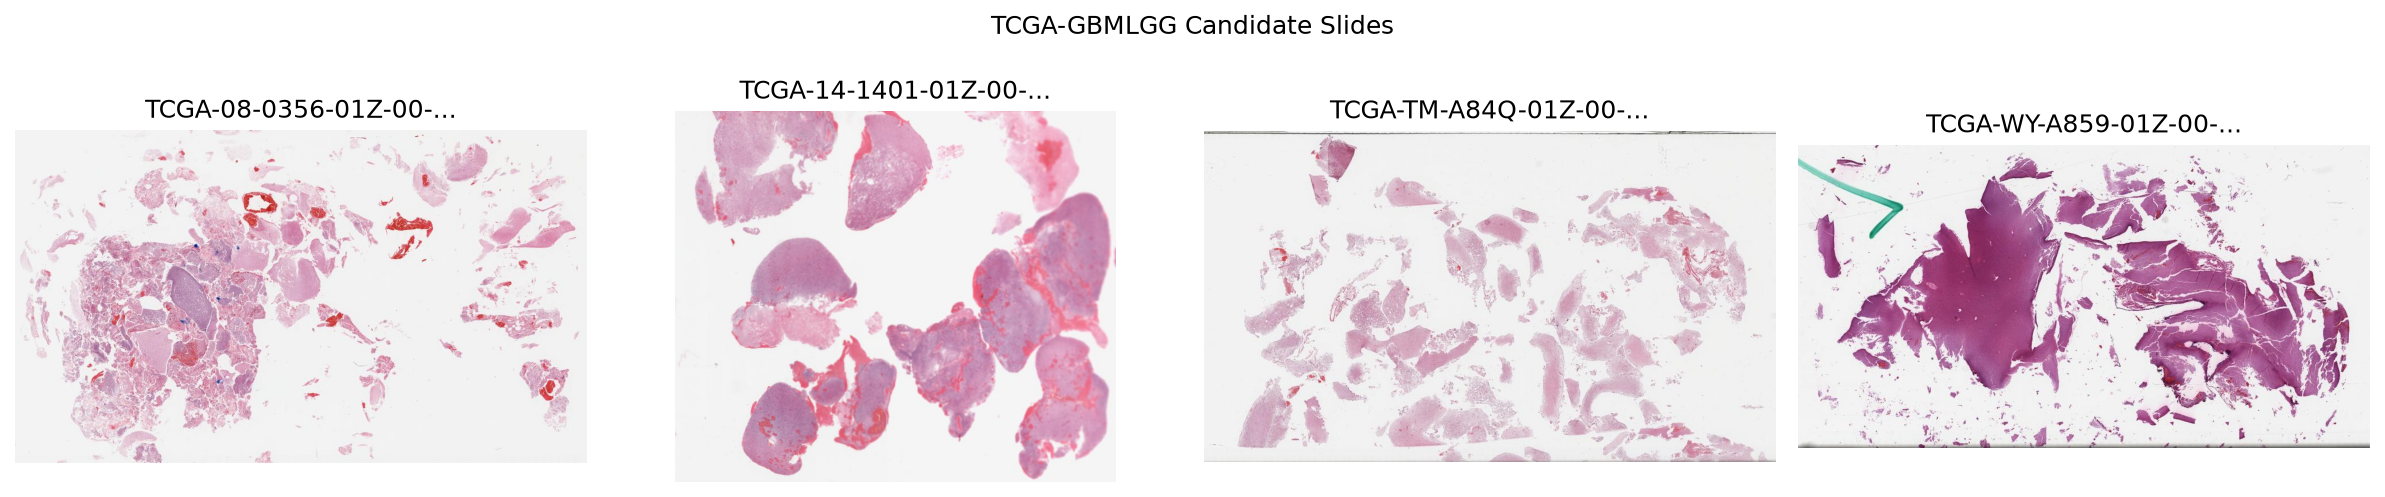

In [4]:
# Rank every processed slide by tissue fragmentation
def n_fragments(stem):
    """Number of disjoint tissue polygons in a slide's Trident geojson."""
    gj = GEOJSON_DIR / f"{stem}.geojson"
    if not gj.exists():
        return 0
    n = 0
    for feat in json.loads(gj.read_text()).get("features", []):
        geom = feat["geometry"]
        if geom["type"] == "Polygon":
            n += 1
        elif geom["type"] == "MultiPolygon":
            n += len(geom["coordinates"])
    return n

stems = sorted(p.stem for p in THUMBNAILS_DIR.glob("*.jpg"))
frags = {s: n_fragments(s) for s in stems}   # compute once, not once per comparison

have_geojson = any(frags.values())
ranked = sorted(stems, key=lambda s: frags[s], reverse=True)

# Gallery of the candidate slides
N_SHOW = 4
sel = ranked[:N_SHOW]
ncol = 4
nrow = int(np.ceil(len(sel) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.2 * nrow))
for ax, s in zip(axes.ravel(), sel):
    ax.imshow(Image.open(THUMBNAILS_DIR / f"{s}.jpg"))
    ax.set_title(f"{s[:20]}...{f' ({frags[s]} frags)' if have_geojson else ''}", fontsize=12)
    ax.axis("off")
for ax in axes.ravel()[len(sel):]:
    ax.axis("off")
fig.suptitle("TCGA-GBMLGG Candidate Slides", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "preprocessing_wsi_examples.png", dpi=600, bbox_inches="tight")
plt.show()

In [5]:
# Choose the slide for Figure 1
SLIDE_STEM = "TCGA-08-0356-01Z-00-DX1.8E74B4EF-3D96-43F6-BAD5-4A33C9B21B6E"

stem = SLIDE_STEM if SLIDE_STEM is not None else ranked[0]

thumb_path   = THUMBNAILS_DIR / f"{stem}.jpg"
contour_path = CONTOURS_DIR   / f"{stem}.jpg"
patches_path = PATCHES_DIR    / f"{stem}_patches.h5"

# Best-effort: map the stem back to its case id for the figure caption
def stem_to_case(stem):
    for _, r in survival_table.iterrows():
        if any(Path(n).stem == stem for n in ast.literal_eval(r["file_names"])):
            return r["submitter_id"]
    return stem.split(".")[0]

survival_table = pd.read_csv(SURVIVAL_TABLE_PATH)
case_id = stem_to_case(stem)

print(f"Case:\t{case_id}")
print(f"Slide:\t{stem}")
for p in (thumb_path, contour_path, patches_path):
    print(f"\t{'OK ' if p.exists() else 'MISSING'} {p.relative_to(PROJECT_ROOT)}")

Case:	TCGA-08-0356
Slide:	TCGA-08-0356-01Z-00-DX1.8E74B4EF-3D96-43F6-BAD5-4A33C9B21B6E
	OK  data/processed/trident/TCGA_GBMLGG/work/thumbnails/TCGA-08-0356-01Z-00-DX1.8E74B4EF-3D96-43F6-BAD5-4A33C9B21B6E.jpg
	OK  data/processed/trident/TCGA_GBMLGG/work/contours/TCGA-08-0356-01Z-00-DX1.8E74B4EF-3D96-43F6-BAD5-4A33C9B21B6E.jpg
	OK  data/processed/trident/TCGA_GBMLGG/work/patches/TCGA-08-0356-01Z-00-DX1.8E74B4EF-3D96-43F6-BAD5-4A33C9B21B6E_patches.h5


In [6]:
# Load the pre-computed artifacts
wsi_thumbnail = Image.open(thumb_path).convert("RGB")
seg_overlay   = Image.open(contour_path).convert("RGB")

with h5py.File(patches_path, "r") as f:
    coords = f["coords"][:]                     # level-0 top-left corners (N, 2)
    a = dict(f["coords"].attrs)
patch_size_level0 = int(a["patch_size_level0"]) # patch edge in level-0 px
level0_w, level0_h = int(a["level0_width"]), int(a["level0_height"])
target_mag  = int(a["target_magnification"])
patch_size  = int(a["patch_size"])
n_patches   = len(coords)

# Map level-0 coordinates onto the thumbnail's pixel space.
thumb_w, thumb_h = wsi_thumbnail.size
sx, sy = thumb_w / level0_w, thumb_h / level0_h
rects = [
    Rectangle((x * sx, y * sy), patch_size_level0 * sx, patch_size_level0 * sy)
    for x, y in coords
]

print(f"{n_patches:,} patches  |  {patch_size}x{patch_size} px @ {target_mag}x (level-0 tile = {patch_size_level0} px)")

15,252 patches  |  256x256 px @ 20x (level-0 tile = 512 px)


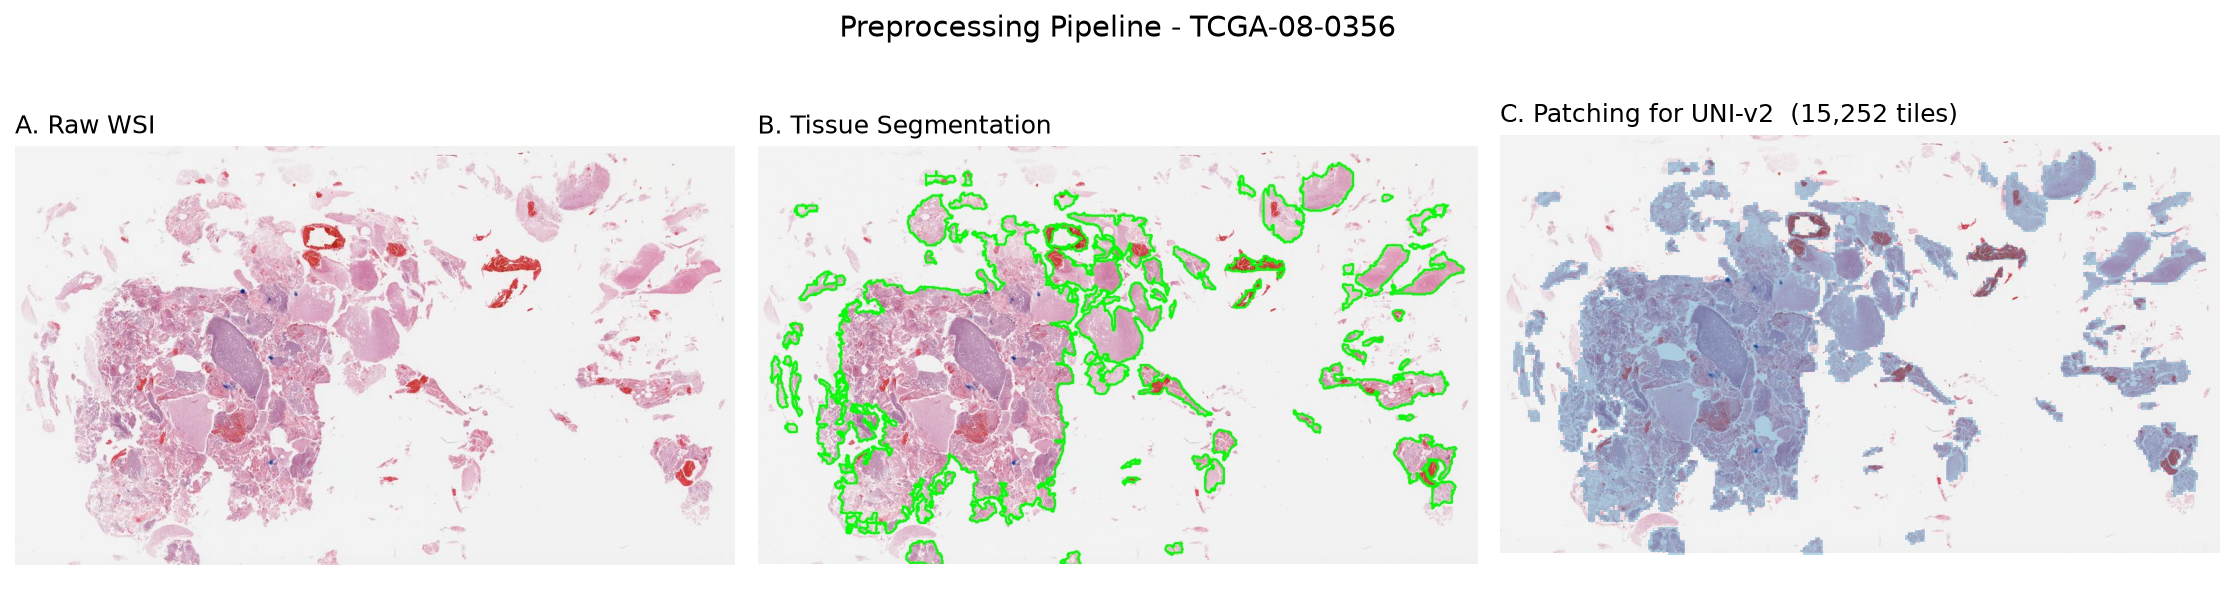

In [7]:
# Assemble the three-panel figure
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

axes[0].imshow(wsi_thumbnail)
axes[0].set_title("A. Raw WSI", fontsize=12, loc="left")

axes[1].imshow(seg_overlay)
axes[1].set_title("B. Tissue Segmentation", fontsize=12, loc="left")

axes[2].imshow(wsi_thumbnail)
axes[2].add_collection(PatchCollection(rects, facecolor="#2b8cbe", edgecolor="none", alpha=0.35))
axes[2].set_title(f"C. Patching for UNI-v2  ({n_patches:,} tiles)", fontsize=12, loc="left")

for ax in axes:
    ax.axis("off")

fig.suptitle(f"Preprocessing Pipeline - {case_id}", fontsize=14, y=.85)
fig.tight_layout()

out_path = FIGURES_DIR / "preprocessing_pipeline.png"
fig.savefig(out_path, dpi=600, bbox_inches="tight")
plt.show()

---
# 3. Training Curves

Per-epoch train/val loss (left) and validation C-index (right), one line per training run (fold, plus the frozen-split model); red dots mark the selected best epoch. Confirms each model converged and early-stopping picked a sensible epoch. Note: train and val loss use different batch sizes (96 vs 4), so their magnitudes aren't comparable.

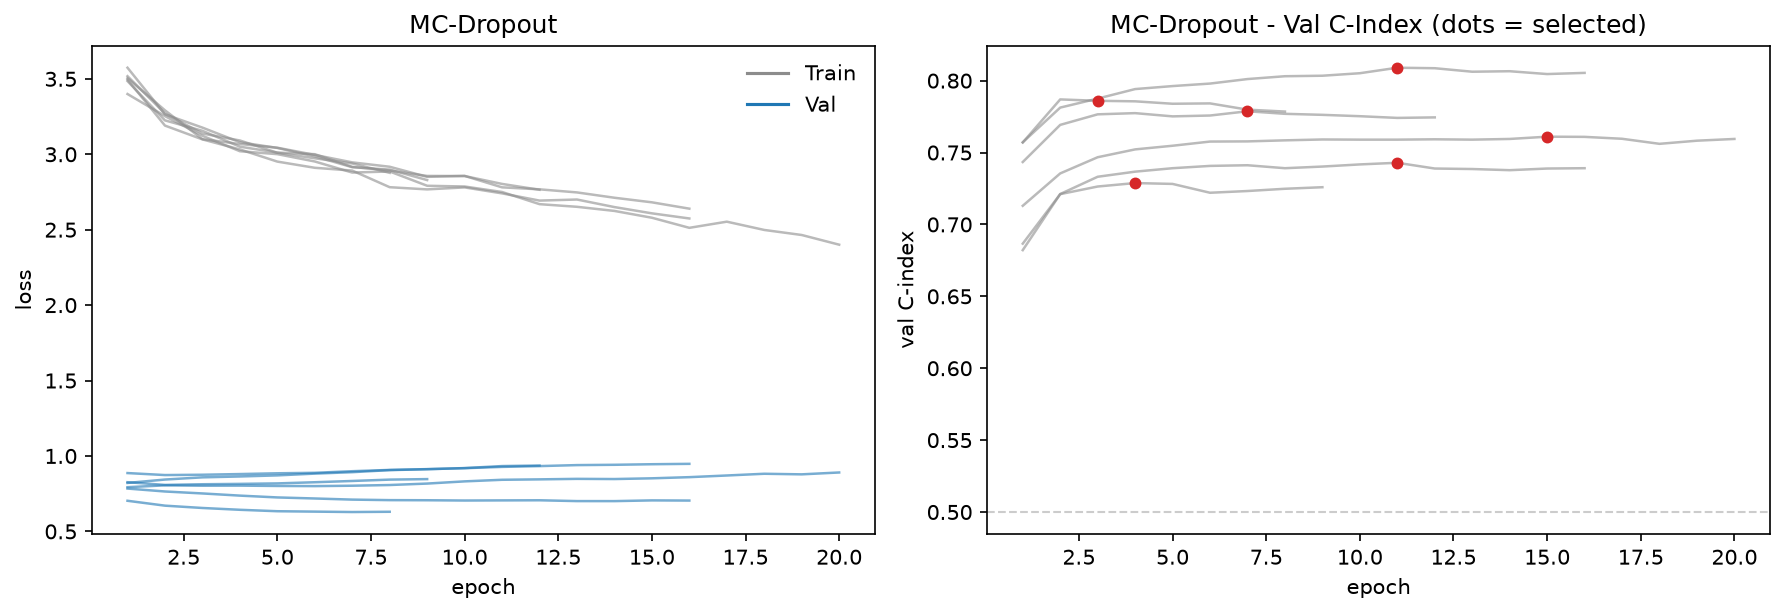

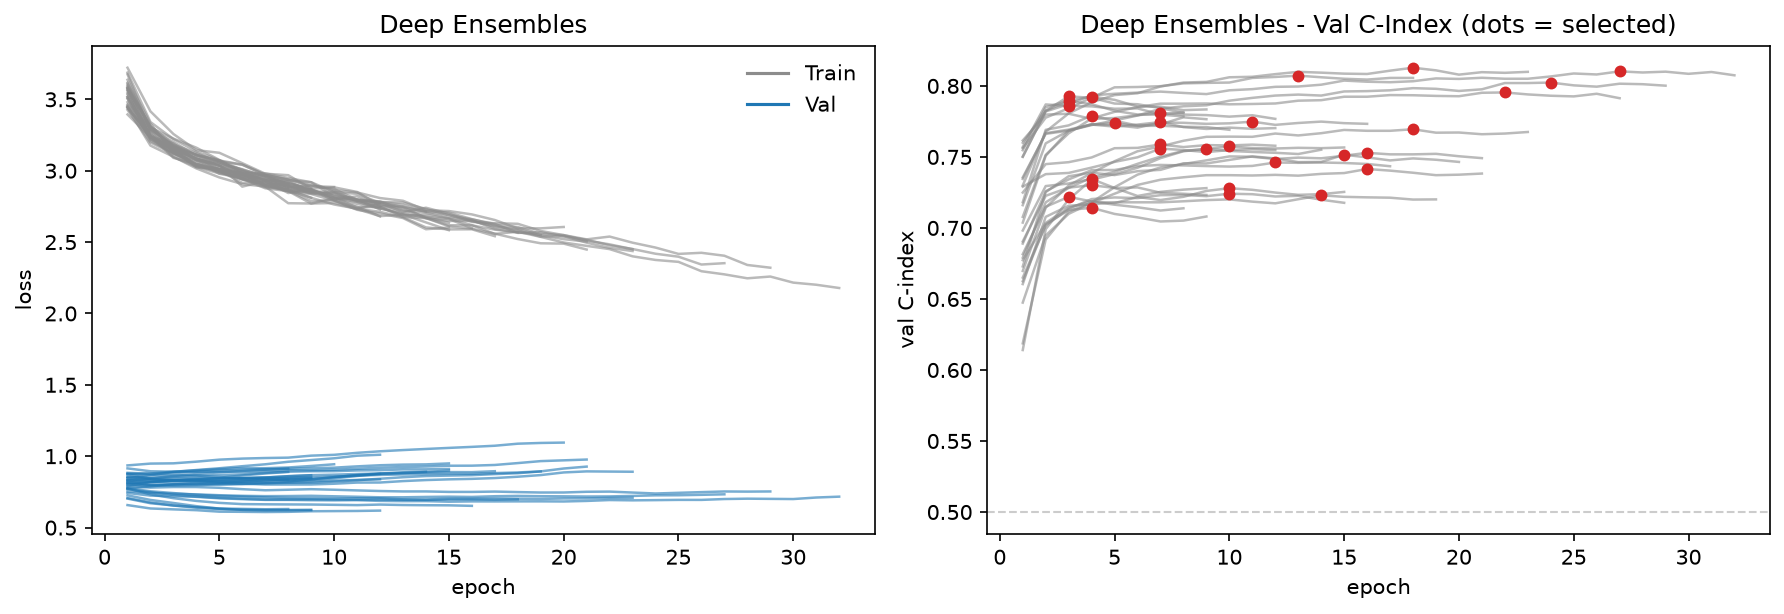

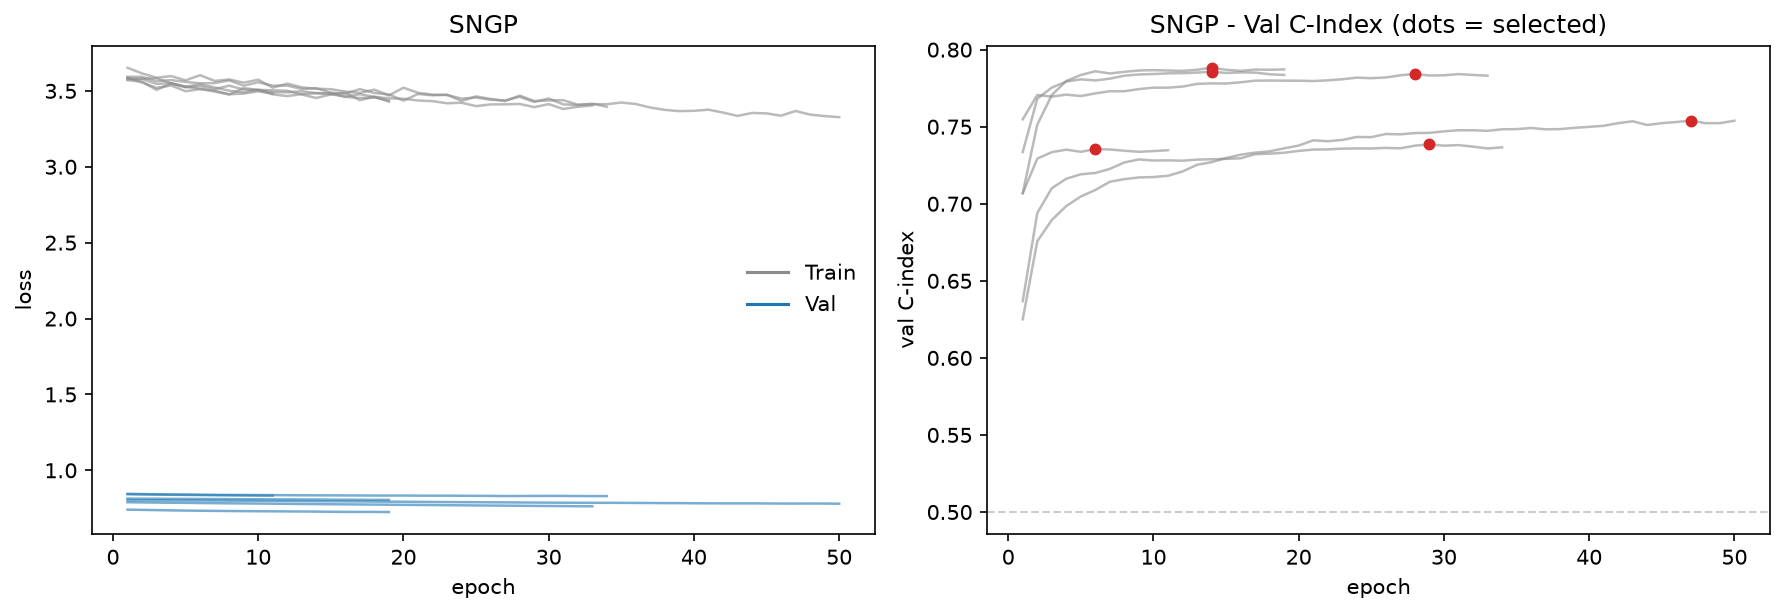

In [8]:
def plot_learning_curves(learning_curves_csv, title):
    lc = pd.read_csv(learning_curves_csv)
    fig, (ax_loss, ax_ci) = plt.subplots(1, 2, figsize=(12, 4.2))
    for _, g in lc.groupby("source"):
        g = g.sort_values("epoch")
        ax_loss.plot(g.epoch, g.train_loss, color="0.55",   lw=1.2, alpha=0.6)
        ax_loss.plot(g.epoch, g.val_loss,   color="#1f77b4", lw=1.2, alpha=0.6)
        ax_ci.plot(g.epoch, g.val_cindex,    color="0.55",   lw=1.2, alpha=0.6)
        best = g[g.is_best_epoch]
        ax_ci.scatter(best.epoch, best.val_cindex, color="#d62728", s=22, zorder=5)
    ax_loss.set(xlabel="epoch", ylabel="loss", title=f"{title}")
    ax_loss.legend(handles=[Line2D([0],[0],color="0.55",label="Train"),
                            Line2D([0],[0],color="#1f77b4",label="Val")], frameon=False)
    ax_ci.axhline(0.5, color="0.8", ls="--", lw=1)
    ax_ci.set(xlabel="epoch", ylabel="val C-index",
              title=f"{title} - Val C-Index (dots = selected)")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"learning_curves_{slug(title)}.png", dpi=600, bbox_inches="tight")
    return fig


for name, path in [("MC-Dropout", MC_DROP_LEARNING_CURVES_PATH),
                   ("Deep Ensembles", ENSEMBLE_LEARNING_CURVES_PATH),
                   ("SNGP", SNGP_LEARNING_CURVES_PATH)]:
    plot_learning_curves(path, name)

---
# 4. Discrimination & Calibration - Prediction Quality

How good are the *predictions*, before we look at uncertainty? Ranking accuracy
(C-index per fold and paired across methods), a held-out test confirmation,
clinical risk stratification (Kaplan-Meier), and probability calibration. All
three UQ methods share the same backbone, so this section is mostly about the
shared model - which is why the methods come out close.

## C-Index Per Fold
Each point is one fold's held-out C-index (concordance); the bar shows the mean across folds, and the dashed line marks random (0.5). Confirms discrimination is stable across folds with no collapsed fold before trusting the pooled estimate.

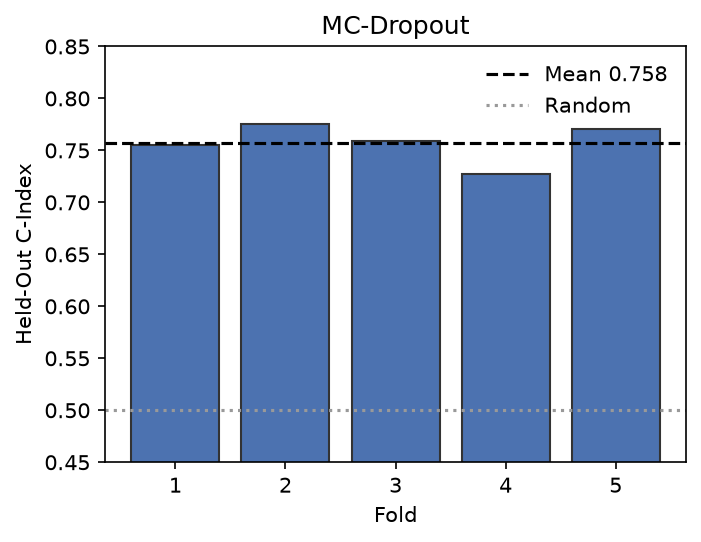

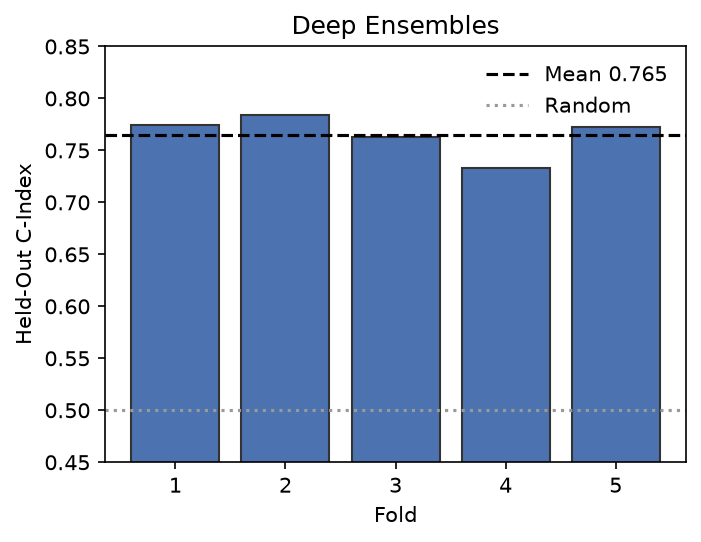

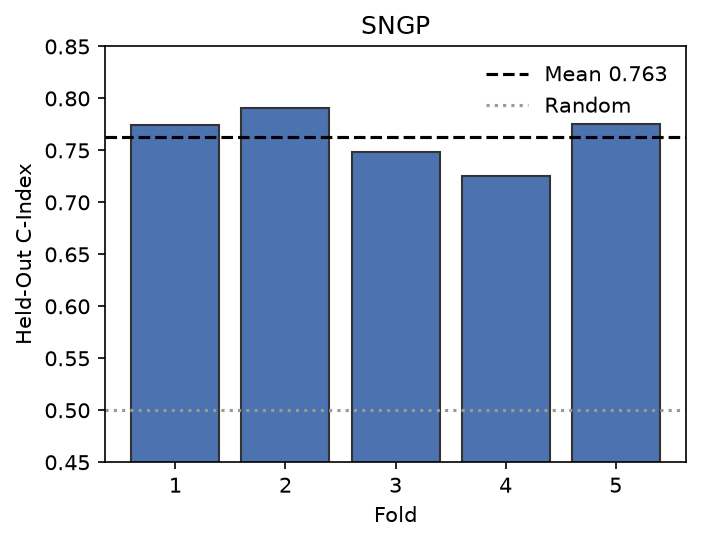

In [9]:
def cindex_per_fold_bars(cv_trials_csv, title=""):
    t = pd.read_csv(cv_trials_csv).sort_values("fold")
    fig, ax = plt.subplots(figsize=(5, 3.6))
    ax.bar(t.fold + 1, t.c_index, color="#4c72b0", edgecolor="0.2")
    ax.axhline(t.c_index.mean(), ls="--", color="k", label=f"Mean {t.c_index.mean():.3f}")
    ax.axhline(0.5, ls=":", color="0.6", label="Random")
    ax.set(xlabel="Fold", ylabel="Held-Out C-Index", title=title,
           xticks=t.fold + 1, ylim=(0.45, 0.85))
    ax.legend(frameon=False)
    fig.savefig(FIGURES_DIR / f"c_index_perfold_{slug(title)}.png", dpi=600, bbox_inches="tight")
    return fig


for name, path in [("MC-Dropout", MC_DROP_CV_TRIALS_PATH),
                   ("Deep Ensembles", ENSEMBLE_CV_TRIALS_PATH),
                   ("SNGP", SNGP_CV_TRIALS_PATH)]:
    cindex_per_fold_bars(path, name)

## Paired Per-Fold C-Index

Each method's held-out C-index for every fold, laid out fold $\times$ method. The folds are
identical across methods, so each row is a **paired** comparison
on the same held-out patients.

In [10]:
trials = pd.concat(
    [pd.read_csv(r/"cv_trials.csv").assign(method=m)
     for m, r in UQ_ROOTS.items() if (r/"cv_trials.csv").exists()], ignore_index=True)
trials.pivot(index="fold", columns="method", values="c_index")

method,Deep ensembles,MC-dropout,SNGP
fold,,,
0,0.774654,0.755538,0.774204
1,0.783743,0.775556,0.791111
2,0.762726,0.758621,0.748299
3,0.732799,0.727367,0.725427
4,0.772452,0.770435,0.775537


## Held-out test set - point vs UQ discrimination

CV is internal; this is the untouched test split. Also answers "does the MC-averaging / ensembling actually change discrimination?" by comparing each method's deterministic (single) C-index to its stochastic (UQ) C-index.

        method  point  p_lo  p_hi    uq  u_lo  u_hi  n_patients  n_events
    MC-dropout  0.789 0.723 0.854 0.789 0.723 0.854          87        44
Deep ensembles  0.781 0.702 0.847 0.786 0.715 0.851          87        44
          SNGP  0.773 0.699 0.838 0.773 0.699 0.838          87        44

Note: point == UQ C-index (identical ranking) for: MC-dropout, SNGP


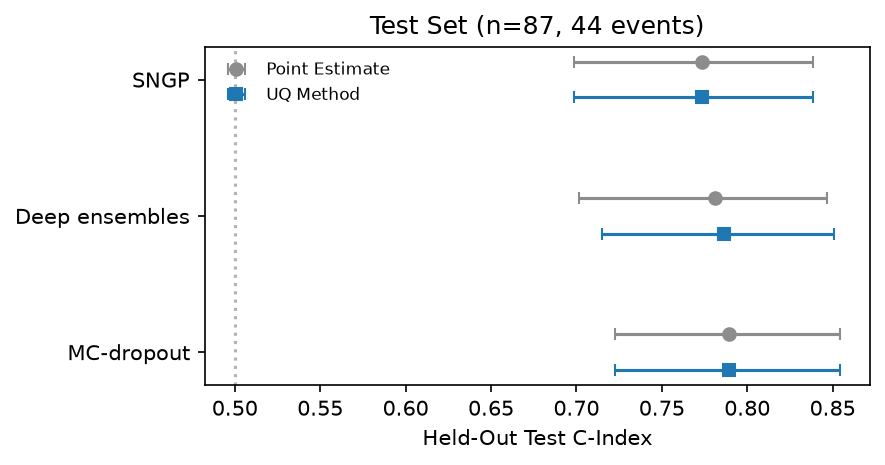

In [11]:
POINT_UQ = {
    "MC-dropout":     ("deterministic", "mc"),
    "Deep ensembles": ("single",        "ensemble"),
    "SNGP":           ("deterministic", "sngp"),
}

rows = []
for m, r in UQ_ROOTS.items():
    f = r / "test_summary.csv"
    if not f.exists(): continue
    s = pd.read_csv(f).iloc[0]
    pt, uq = POINT_UQ[m]
    rows.append(dict(method=m,
        point=s[f"{pt}_cindex"], p_lo=s[f"{pt}_ci_low"], p_hi=s[f"{pt}_ci_high"],
        uq=s[f"{uq}_cindex"],    u_lo=s[f"{uq}_ci_low"], u_hi=s[f"{uq}_ci_high"],
        n_patients=int(s["n_test_patients"]), n_events=int(s["n_test_events"])))
T = pd.DataFrame(rows)
print(T.round(3).to_string(index=False))

# The three methods must share the test split for a single title to be honest about it.
if T.n_patients.nunique() != 1 or T.n_events.nunique() != 1:
    raise ValueError("methods do not share a test split; the shared title would misreport it")
n_patients, n_events = int(T.n_patients[0]), int(T.n_events[0])

identical = T[np.isclose(T.point, T.uq)].method.tolist()

fig, ax = plt.subplots(figsize=(6, 3.2))
for i, row in T.iterrows():
    ax.errorbar(row.point, i + 0.13, xerr=[[row.point - row.p_lo], [row.p_hi - row.point]], fmt="o", color="0.55", capsize=3, label="Point Estimate" if i == 0 else None)
    ax.errorbar(row.uq, i - 0.13, xerr=[[row.uq - row.u_lo], [row.u_hi - row.uq]], fmt="s", color="#1f77b4", capsize=3, label="UQ Method" if i == 0 else None)
ax.axvline(0.5, ls=":", color="0.7")
ax.set(yticks=range(len(T)), yticklabels=T.method, xlabel="Held-Out Test C-Index",
       title=f"Test Set (n={n_patients}, {n_events} events)")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "test_cindex.png", dpi=600, bbox_inches="tight")

if identical:
    print(f"\nNote: point == UQ C-index (identical ranking) for: {', '.join(identical)}")

## Kaplan-Meier Survival Stratified by Predicted Risk

We split the patients into three groups (Low / Mid / High) by the survival risk our model predicted, then plotted each group's actual Kaplan Meier survival curve over time. If the model correctly stratifies risk, the high-risk group should show worse survival. The clear, correctly-ordered separation between the curves confirms it does. The log-rank test also demonstrates the separation between the curves is real and not just by chance.

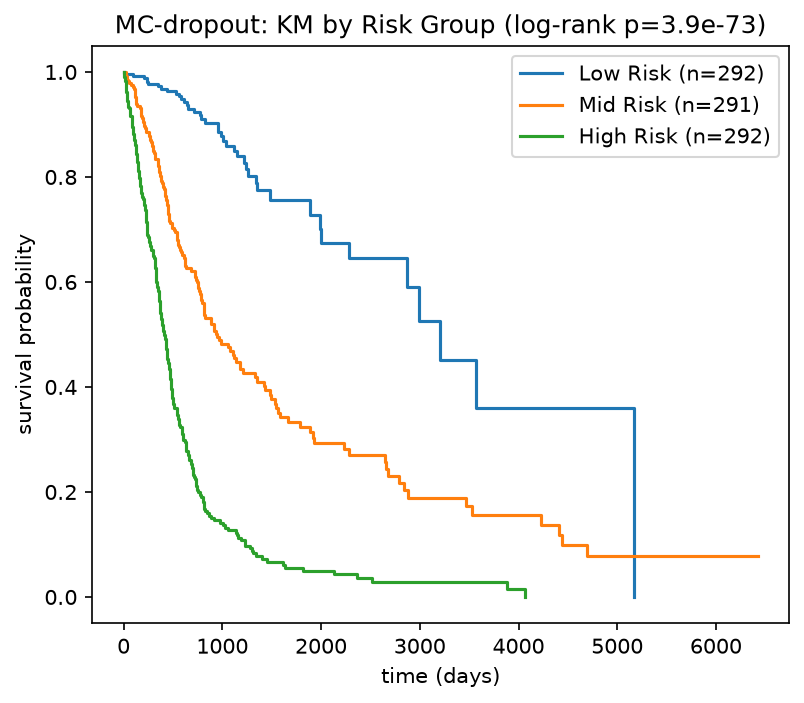

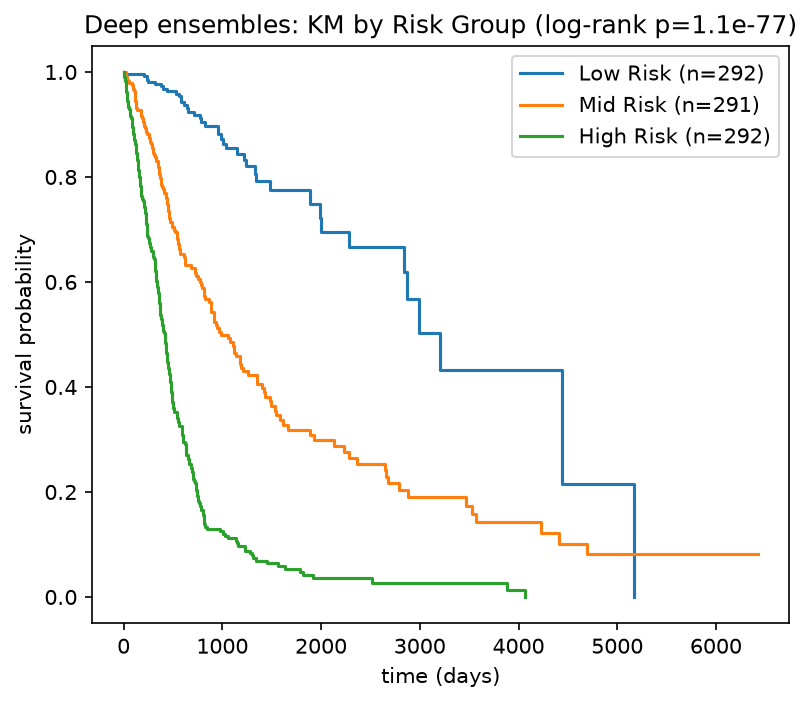

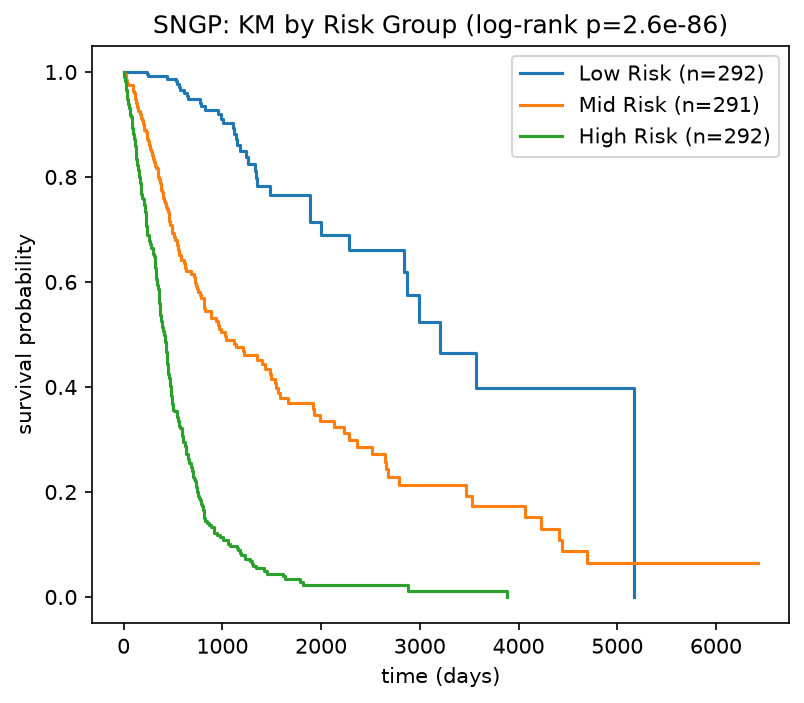

In [12]:
def km_by_risk(pooled, n_groups=3, title=""):
    p = pooled.copy()
    labels = ["Low", "Mid", "High"] if n_groups == 3 else [f"Q{i+1}" for i in range(n_groups)]
    p["grp"] = pd.qcut(p.risk_mean, n_groups, labels=labels)   # Q1 = lowest predicted risk
    fig, ax = plt.subplots(figsize=(6, 5))
    kmf = KaplanMeierFitter()
    for g, sub in p.groupby("grp", observed=True):
        kmf.fit(sub.time, sub.event, label=f"{g} Risk (n={len(sub)})")
        kmf.plot_survival_function(ax=ax, ci_show=False)
    p_val = multivariate_logrank_test(p.time, p.grp, p.event).p_value
    ax.set(xlabel="time (days)", ylabel="survival probability",
           title=f"{title}: KM by Risk Group (log-rank p={p_val:.1e})")
    fig.savefig(FIGURES_DIR / f"km_{slug(title)}.png", dpi=600, bbox_inches="tight")
    return fig


for m in POOLED:
    km_by_risk(POOLED[m], title=m)

## Calibration - Predicted vs Observed Survival at Fixed Horizons
A Cox head emits a relative risk score, not an absolute survival probability. We reconstruct $S(t|x)$ with a Breslow baseline fit on the pooled out-of-fold risk scores, then bin patients by predicted survival and compare the bin's mean prediction to the observed Kaplan-Meier survival at the horizon.

**The risk scores are z-scored within fold first** (`Z_BY_FOLD`). This is not cosmetic: the five folds are five separately-fit models, and a Breslow baseline can absorb a per-model *offset* but not a per-model *scale*. On raw scores SNGP looked badly miscalibrated (mean MCE 0.20 vs ~0.08) purely because its GP head emits a compressed risk scale (sd 0.18 against ~1.4 for the others), which squeezes predicted survival into a narrow band. On a common within-fold scale that artifact disappears and SNGP is the best-calibrated of the three.

Caveats: the baseline is fit in-sample on the pooled predictions (the *risk scores* are still out-of-fold); within-fold standardisation is itself a recalibration, so this measures calibration *after* refitting scale and baseline, not the raw model's absolute-risk output; and it assumes the Cox proportional-hazards form.

1-yr	MC-dropout       MCE=0.054
1-yr	Deep ensembles   MCE=0.042
1-yr	SNGP             MCE=0.036
3-yr	MC-dropout       MCE=0.063
3-yr	Deep ensembles   MCE=0.052
3-yr	SNGP             MCE=0.044
5-yr	MC-dropout       MCE=0.046
5-yr	Deep ensembles   MCE=0.033
5-yr	SNGP             MCE=0.033

Raw (un-z-scored) risk scale, for reference:
	MC-dropout       risk_mean std=1.397 range=[-4.39, 2.36]
	Deep ensembles   risk_mean std=1.410 range=[-3.73, 2.37]
	SNGP             risk_mean std=0.181 range=[-0.41, 0.25]


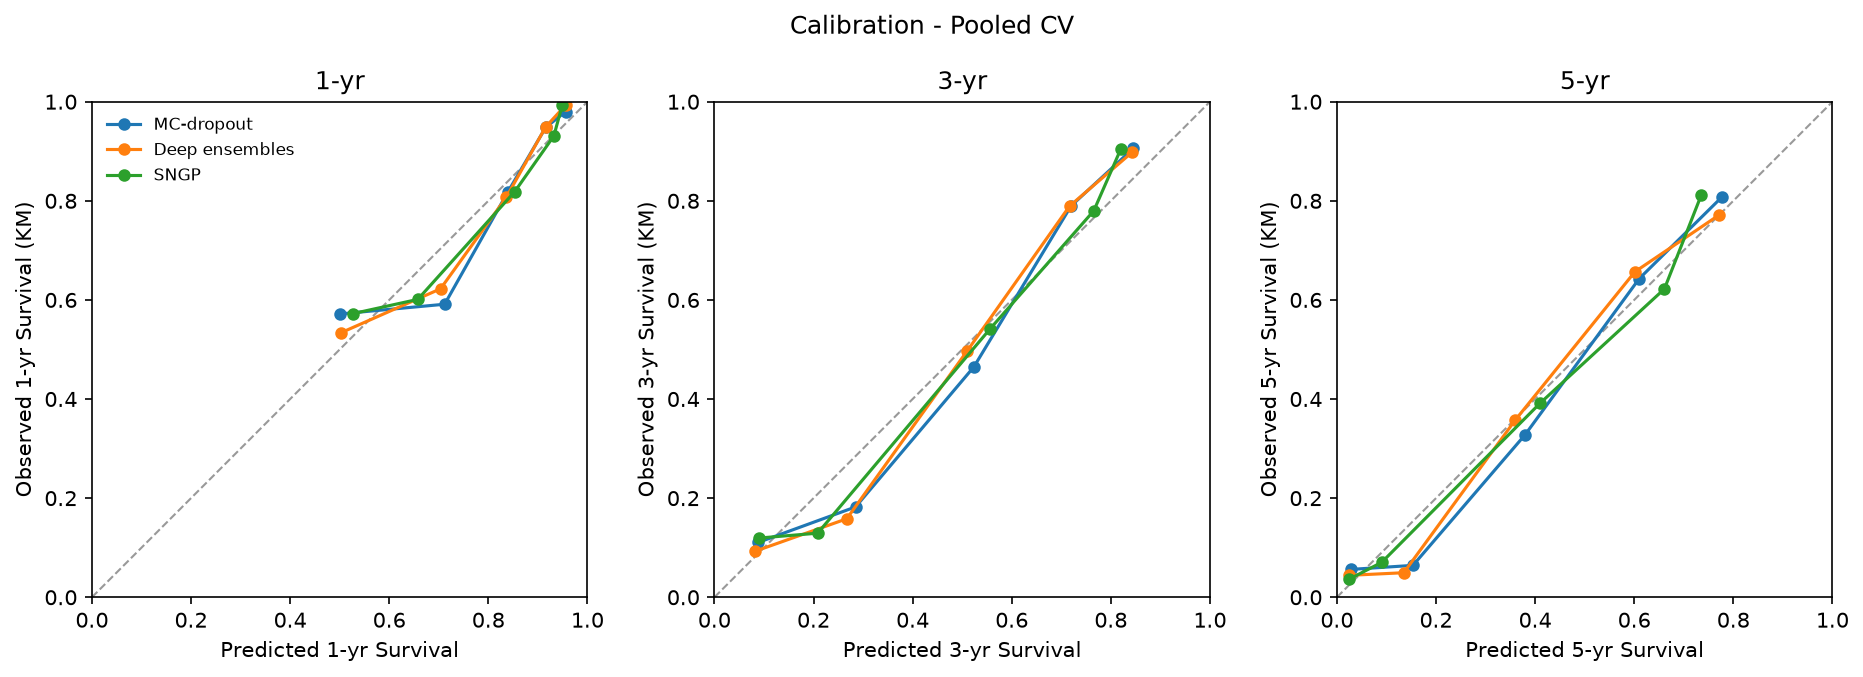

In [13]:
def breslow_baseline(risk, time, event):
    """Breslow estimate of baseline cumulative hazard H0 at each event time."""
    risk, time, event = (np.asarray(x, float) for x in (risk, time, event))
    exp_eta = np.exp(risk)
    ev_times = np.unique(time[event == 1])
    H0 = []
    for t in ev_times:
        d = np.sum((time == t) & (event == 1))       # deaths at t (handles ties)
        at_risk = exp_eta[time >= t].sum()           # sum exp(eta) still at risk
        H0.append(d / at_risk)
    return ev_times, np.cumsum(H0)

def predicted_survival(risk, ev_times, H0_cum, horizon):
    """S(horizon | x) = exp(-H0(horizon) * exp(eta))."""
    if horizon < ev_times[0]:
        H0_at = 0.0
    else:
        H0_at = H0_cum[np.searchsorted(ev_times, horizon, side="right") - 1]
    return np.exp(-H0_at * np.exp(np.asarray(risk, float)))

def calibration_points(df, horizon, n_bins=5):
    ev_t, H0 = breslow_baseline(df.risk_mean, df.time, df.event)
    d = df.assign(S_pred=predicted_survival(df.risk_mean, ev_t, H0, horizon))
    d["bin"] = pd.qcut(d.S_pred, n_bins, duplicates="drop")
    kmf, xs, ys = KaplanMeierFitter(), [], []
    for _, sub in d.groupby("bin", observed=True):
        kmf.fit(sub.time, sub.event)
        xs.append(sub.S_pred.mean()); ys.append(float(kmf.predict(horizon)))
    return np.array(xs), np.array(ys)

HORIZONS = {"1-yr": 365, "3-yr": 1095, "5-yr": 1825}

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(4.2 * len(HORIZONS), 4.2))
for ax, (hlabel, hdays) in zip(axes, HORIZONS.items()):
    ax.plot([0, 1], [0, 1], ls="--", color="0.6", lw=1)
    for m, df in POOLED.items():
        x, y = calibration_points(df, hdays)
        ax.plot(x, y, marker="o", ms=5, label=m)
        mce = np.mean(np.abs(x - y))
        print(f"{hlabel}\t{m:16s} MCE={mce:.3f}")
    ax.set(xlim=(0, 1), ylim=(0, 1), aspect="equal", xlabel=f"Predicted {hlabel} Survival", ylabel=f"Observed {hlabel} Survival (KM)", title=hlabel)
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f"Calibration - Pooled CV", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "calibration.png", dpi=600, bbox_inches="tight")

# The raw scales are what made the Breslow baseline incomparable across methods.
print("\nRaw (un-z-scored) risk scale, for reference:")
for m, r in UQ_ROOTS.items():
    d = load_pooled(r, z=False)
    print(f"\t{m:16s} risk_mean std={d.risk_mean.std():.3f} range=[{d.risk_mean.min():.2f}, {d.risk_mean.max():.2f}]")

## Cross-Method Summary

Pooled whole-cohort C-index (with 95% bootstrap CI), the mean $\pm$ std across folds, and the
mean calibration error (MCE, averaged over the three horizons) for each UQ method, side by side.

`pooled_cindex_raw` is the number `cv_summary.csv` reports from raw-scale pooling, kept for
comparison - the gap is the size of the fold-scale artifact (largest for SNGP, which raw pooling
made look like the *worst* method on discrimination).

Note: the selective-AUC in `cv_summary.csv` (`mean_selective_auc`) integrates over the full
coverage range, while the "Area" reported in the selective-prediction section below applies the
`MIN_COVERAGE = 0.2` floor. They are different quantities - don't quote them interchangeably.

In [14]:
def method_mce(df, n_bins=5):
    """Mean absolute calibration error, averaged over HORIZONS."""
    return np.mean([np.mean(np.abs(np.subtract(*calibration_points(df, h, n_bins))))
                    for h in HORIZONS.values()])

# --- Cross-method summary: discrimination (pooled C-index) + calibration (MCE) ---
#
# pooled_cindex / pooled_ci_* in cv_summary.csv were computed on the RAW pooled scores,
# so they are recomputed here on the within-fold-z-scored scores. mean_cindex/std_cindex
# are per-fold quantities and are unaffected by pooling, so they come straight from the CSV.
rows = []
for m, root in UQ_ROOTS.items():
    if not (root / "cv_summary.csv").exists():
        continue
    cv = pd.read_csv(root / "cv_summary.csv").iloc[0]
    point, lo, hi = pooled_cindex_ci(POOLED[m])
    rows.append({
        "method":          m,
        "pooled_cindex":   point,
        "pooled_ci_low":   lo,
        "pooled_ci_high":  hi,
        "mean_cindex":     cv["mean_cindex"],
        "std_cindex":      cv["std_cindex"],
        "mean_mce":        method_mce(POOLED[m]),
        "pooled_cindex_raw": cv["pooled_cindex"],   # what raw-scale pooling reported
    })

summary = pd.DataFrame(rows)
summary.round(3)

,method,pooled_cindex,pooled_ci_low,pooled_ci_high,mean_cindex,std_cindex,mean_mce,pooled_cindex_raw
0,MC-dropout,0.758,0.735,0.780,0.758,0.019,0.054,0.755
1,Deep ensembles,0.765,0.744,0.786,0.765,0.020,0.042,0.759
2,SNGP,0.763,0.742,0.784,0.763,0.026,0.038,0.744


---
# 5. Uncertainty Evaluation

How good is the *uncertainty* each method produces (`risk_std`)? Whether dropping
the least-confident patients improves accuracy above a random-subset null
(selective prediction), and whether that signal survives once the risk score is
accounted for (confound analysis). This is where the methods actually differ.

## Selective Prediction - Uncertainty Informativeness

Each curve recomputes the pooled-CV C-index on the retained patients as the most-uncertain are progressively dropped (right = all patients, left = only the most confident). If uncertainty is informative, accuracy should rise as coverage shrinks.

MC-dropout       C-index 0.758 (all patients) -> 0.849 (at 22% coverage)  lift +0.091
Deep ensembles   C-index 0.765 (all patients) -> 0.802 (at 22% coverage)  lift +0.037
SNGP             C-index 0.763 (all patients) -> 0.852 (at 22% coverage)  lift +0.089


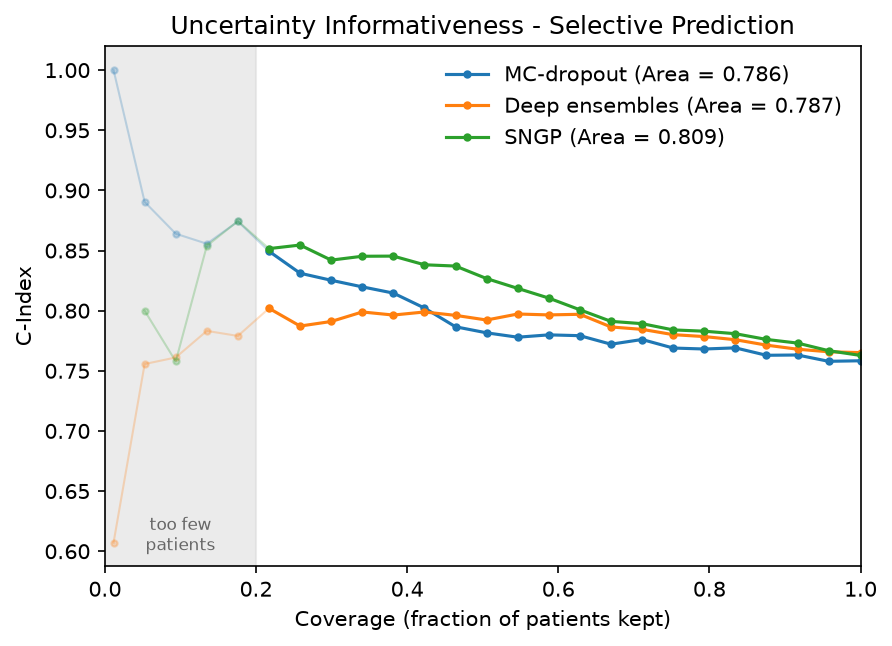

In [15]:
MIN_COVERAGE = 0.2   # Trust floor

def _safe_cindex(t, s, e):
    try:    return ll_cindex(t, s, e)
    except ZeroDivisionError: return np.nan      # no admissible pairs in this tiny subset

def selective_curve(df, min_patients=10, n_points=25):
    d = df.sort_values("risk_std").reset_index(drop=True); n = len(d)
    ks = np.unique(np.linspace(min(min_patients, n), n, n_points).astype(int))
    cov, cidx = [], []
    for k in ks:
        s = d.iloc[:k]
        c = _safe_cindex(s.time.to_numpy(), -s.risk_mean.to_numpy(), s.event.to_numpy())
        if np.isfinite(c): cov.append(k/n); cidx.append(c)
    return np.array(cov), np.array(cidx)

def selective_area(cov, cidx, lo):
    """Normalized area under the curve over the trustworthy range cov >= lo."""
    m = cov >= lo
    if m.sum() < 2: return np.nan
    return np.trapezoid(cidx[m], cov[m]) / (cov[m][-1] - cov[m][0])

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for m, df in POOLED.items():
    cov, cidx = selective_curve(df)
    auc = selective_area(cov, cidx, MIN_COVERAGE)
    j = np.searchsorted(cov, MIN_COVERAGE, side="left")   # first trusted index
    # Lift = how much accuracy the filtering actually buys: C at the trust floor minus
    # C at full coverage. (The max-minus-min "spread" this used to print is positive by
    # construction and says nothing about whether accuracy *rose* as coverage shrank.)
    lift = cidx[j] - cidx[-1]
    print(f"{m:16s} C-index {cidx[-1]:.3f} (all patients) -> {cidx[j]:.3f} "
          f"(at {cov[j]:.0%} coverage)  lift {lift:+.3f}")
    line, = ax.plot(cov[j:], cidx[j:], marker="o", ms=3, label=f"{m} (Area = {auc:.3f})")
    ax.plot(cov[:j+1], cidx[:j+1], marker="o", ms=3, color=line.get_color(), alpha=0.25, lw=1)

ax.axvspan(0, MIN_COVERAGE, color="0.85", alpha=0.5, zorder=0)
ax.text(MIN_COVERAGE/2, 0.02, "too few\npatients", transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=8, color="0.4")
ax.set(xlim=(0, 1), xlabel="Coverage (fraction of patients kept)", ylabel="C-Index", title="Uncertainty Informativeness - Selective Prediction")
ax.legend(frameon=False)
fig.savefig(FIGURES_DIR / "uncertainty_informativeness.png", dpi=600, bbox_inches="tight")

## Selective-prediction null - is the lift above chance?
For each coverage k/n a *random* subset of size k also scores above baseline (smaller sample + easy risk-tails). If the confidence-ranked curve sits above his random-subset band, the uncertainty is informative above chance.
The observed curve and the null band both use lifelines' C-index (see _safe_cindex), so they agree on tie handling -- comparing a curve from one implementation against a band from another would be apples-to-oranges.

In [16]:
# Random-subset null band for the selective-prediction curves.
#
# For each coverage k/n, a *random* subset of size k also tends to score above the
# whole-cohort baseline (smaller sample, plus the easy risk tails), so "beats the full
# cohort" is not enough -- the confidence-ranked curve has to clear this null band.
# We compute the band once here and reuse it in the final "beyond the risk score" figure
# below, so it is only *plotted* once (there), not twice.
#
# The null uses lifelines' C-index (via _safe_cindex), matching the observed curves, so
# the two agree on tie handling.

def selective_null(df, n_shuffle=200, min_patients=10, n_points=25, seed=0):
    rng = np.random.default_rng(seed); n = len(df)
    ks = np.unique(np.linspace(min(min_patients, n), n, n_points).astype(int))
    risk, time, event = df.risk_mean.to_numpy(), df.time.to_numpy(), df.event.to_numpy()
    curves = np.full((n_shuffle, len(ks)), np.nan)
    for b in range(n_shuffle):
        perm = rng.permutation(n)
        for i, k in enumerate(ks):
            idx = perm[:k]
            curves[b, i] = _safe_cindex(time[idx], -risk[idx], event[idx])  # -risk: higher risk = shorter life
    return ks / n, np.nanpercentile(curves, 5, axis=0), np.nanpercentile(curves, 95, axis=0)

# Precompute per-method null bands; the final "beyond the risk score" figure reuses these.
NULL_BANDS = {m: selective_null(df) for m, df in POOLED.items()}

In [17]:
def selective_area_pvalue(df, n_shuffle=2000, lo=MIN_COVERAGE, seed=0):
    cov, cidx = selective_curve(df)
    obs = selective_area(cov, cidx, lo)
    rng = np.random.default_rng(seed); n = len(df)
    risk, time, event = df.risk_mean.to_numpy(), df.time.to_numpy(), df.event.to_numpy()
    ks = np.unique(np.linspace(min(10, n), n, 25).astype(int)); ncov = ks / n
    null = np.empty(n_shuffle)
    for b in range(n_shuffle):
        perm = rng.permutation(n)
        nc = np.array([_safe_cindex(time[perm[:k]], -risk[perm[:k]], event[perm[:k]]) for k in ks])
        null[b] = selective_area(ncov, nc, lo)
    p = (np.sum(null >= obs) + 1) / (n_shuffle + 1)      # one-sided
    return obs, p

for m, df in POOLED.items():
    obs, p = selective_area_pvalue(df)
    print(f"{m:16s} area={obs:.3f}  p={p:.3f}")

MC-dropout       area=0.786  p=0.000
Deep ensembles   area=0.787  p=0.003
SNGP             area=0.809  p=0.000


## Is the uncertainty informative *beyond the risk score*?

The selective-prediction curves above beat the random-subset null, but that
only shows the ranking is better than *random*, not that it required UQ. Three
confounds could produce the same lift for free:

1. **Risk-level coupling.** If uncertainty correlates with the risk score,
   filtering by confidence just keeps a low- (or high-) risk subpopulation.
2. **Risk-extremity coupling.** If uncertainty is lowest at extreme risk,
   filtering keeps the tails and discards the middle, leaving a bimodal set
   that is *mechanically* easier to rank.
3. **Fold coupling.** The pooled patients were scored by five different models.
   If one fold's model reports systematically larger `risk_std`, then "drop the
   most uncertain" partly means "drop that fold's patients": a model-level
   artifact masquerading as patient-level uncertainty. On the raw scores this
   was severe: for SNGP the 20% most-confident patients contained **64** from
   fold 1 and **zero** from fold 4 (an even split would be ~35 each).

Confound 3 is why `Z_BY_FOLD = True`. Because only the *order* of `risk_std`
matters for selective prediction, it is converted to a within-fold **percentile
rank** rather than z-scored: z-scoring equalises each fold's mean and spread but
not the *shape* of its tail, and MC-dropout's fold 3 is skewed enough (skew 6.1)
that even after z-scoring none of its patients reach the confident 20%. A
percentile rank makes the retained set exactly fold-balanced (35/35/35/35/35 at
20% coverage, as the diagnostic below confirms). The `fold` column it needs is
not in `cv_pooled_predictions.csv`; it is reconstructed from row order and
verified against `cv_trials.csv` in the setup section above.

For confounds 1 and 2 we run three diagnostics:

- **Correlations** of uncertainty with `risk` and with `|risk - median|`.
- **Free baselines**: repeat the coverage sweep ranking by risk-derived scores
  that require no UQ. If a free score matches the uncertainty curve, the UQ
  added no information.
- **Residualised uncertainty**: regress uncertainty on risk (non-parametric),
  re-rank on the residual. What survives is signal orthogonal to risk.

These probe different things and need not agree; we report all three.

> The fold composition of the retained set is printed below: check it stays near
> even. If one fold dominates the confident tail, the "lift" is still a fold effect.

In [18]:
def selective_curve_by(df, score, min_patients=10, n_points=25):
    """As selective_curve, but rank by an arbitrary score (ascending = kept first)."""
    n = len(df)
    order = np.argsort(np.asarray(score), kind="mergesort")
    risk, time, event = df.risk_mean.to_numpy(), df.time.to_numpy(), df.event.to_numpy()
    ks = np.unique(np.linspace(min(min_patients, n), n, n_points).astype(int))
    cov, cidx = [], []
    for k in ks:
        i = order[:k]
        c = _safe_cindex(time[i], -risk[i], event[i])
        if np.isfinite(c):
            cov.append(k / n); cidx.append(c)
    return np.array(cov), np.array(cidx)

def free_scores(df):
    """Confidence scores derivable from the point estimate alone - no UQ needed."""
    r = df.risk_mean.to_numpy()
    return {"risk (low first)":        r,
            "risk (high first)":      -r,
            "|risk-med| (extremes)":  -np.abs(r - np.median(r))}

def residualise(df):
    """Remove any component of uncertainty predictable from risk (CV'd, non-parametric).

    One feature, so the regressor must be gentle -- a deep boosted forest overfits the
    single risk column and reports *negative* explained variance even when rho(unc, risk)
    is clearly non-zero. The CV split is shuffled: the pooled rows are ordered by fold, so
    an unshuffled KFold would train and test on different models' scores.
    """
    r = df.risk_mean.to_numpy().reshape(-1, 1)
    u = df.risk_std.to_numpy()
    pred = cross_val_predict(
        GradientBoostingRegressor(max_depth=2, n_estimators=100, learning_rate=0.05,
                                  min_samples_leaf=20, random_state=0),
        r, u, cv=KFold(n_splits=5, shuffle=True, random_state=0))
    resid = u - pred
    return resid, 1 - np.var(resid) / np.var(u)   # var of unc explained by risk

def confident_fold_mix(df, coverage=MIN_COVERAGE):
    """Fold composition of the most-confident `coverage` fraction (should be ~even)."""
    k = int(coverage * len(df))
    keep = df.nsmallest(k, "risk_std")
    counts = keep.fold.value_counts().reindex(sorted(df.fold.unique()), fill_value=0)
    return counts.to_dict(), k / df.fold.nunique()

rows = []
for m, df in POOLED.items():
    r, u = df.risk_mean.to_numpy(), df.risk_std.to_numpy()

    area_unc = selective_area(*selective_curve_by(df, u), MIN_COVERAGE)

    free = {n: selective_area(*selective_curve_by(df, s), MIN_COVERAGE)
            for n, s in free_scores(df).items()}
    best_free_name = max(free, key=free.get)

    u_res, var_expl = residualise(df)
    area_res = selective_area(*selective_curve_by(df, u_res), MIN_COVERAGE)

    mix, expected = confident_fold_mix(df)
    print(f"{m:16s} fold mix of the {MIN_COVERAGE:.0%} most-confident: {mix}  (even = ~{expected:.0f} each)")

    rows.append({
        "method":            m,
        "pooled C":          ll_cindex(df.time, -df.risk_mean, df.event),
        "rho(unc, risk)":    spearmanr(u, r)[0],
        "rho(unc, |risk-med|)": spearmanr(u, np.abs(r - np.median(r)))[0],
        "var(unc) expl. by risk": var_expl,
        "area: uncertainty": area_unc,
        "area: best free":   free[best_free_name],
        "best free score":   best_free_name,
        "gain over free":    area_unc - free[best_free_name],
        "area: residualised": area_res,
    })

confound = pd.DataFrame(rows).set_index("method")
display(confound.round(3))
confound.to_csv(RESULTS_DIR / "uncertainty_confound_diagnostics.csv")

MC-dropout       fold mix of the 20% most-confident: {0: 35, 1: 35, 2: 35, 3: 35, 4: 35}  (even = ~35 each)
Deep ensembles   fold mix of the 20% most-confident: {0: 35, 1: 35, 2: 35, 3: 35, 4: 35}  (even = ~35 each)
SNGP             fold mix of the 20% most-confident: {0: 35, 1: 35, 2: 35, 3: 35, 4: 35}  (even = ~35 each)


,pooled C,"rho(unc, risk)","rho(unc, |risk-med|)",var(unc) expl. by risk,area: uncertainty,area: best free,best free score,gain over free,area: residualised
method,,,,,,,,,
MC-dropout,0.758,0.339,-0.138,0.118,0.786,0.766,|risk-med| (extremes),0.020,0.763
Deep ensembles,0.765,0.078,-0.028,-0.028,0.786,0.788,|risk-med| (extremes),-0.001,0.782
SNGP,0.763,0.461,-0.275,0.642,0.809,0.719,risk (low first),0.090,0.769


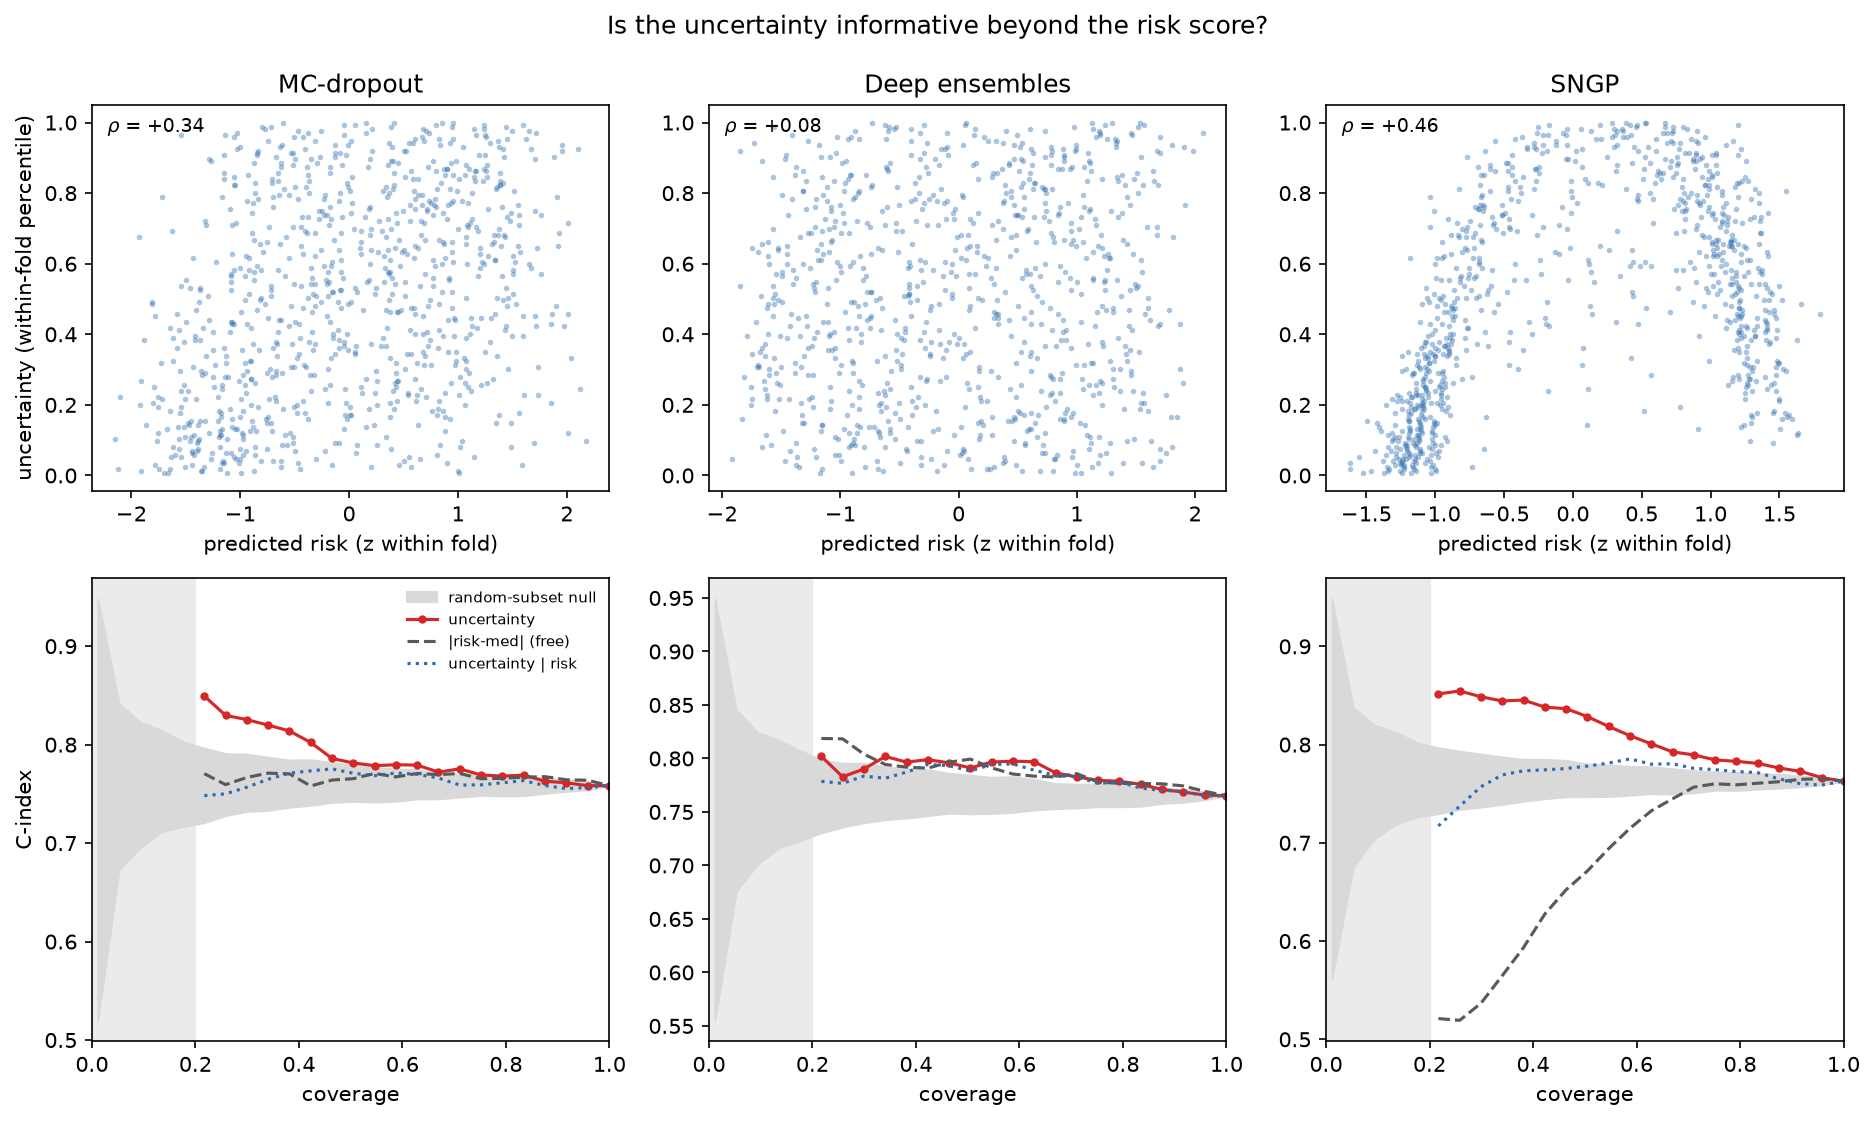

In [19]:
fig, axes = plt.subplots(2, len(POOLED), figsize=(4.2 * len(POOLED), 7.5),
                         gridspec_kw={"height_ratios": [1, 1.2]})
for j, (m, df) in enumerate(POOLED.items()):
    r, u = df.risk_mean.to_numpy(), df.risk_std.to_numpy()

    axes[0, j].scatter(r, u, s=7, alpha=0.4, lw=0, color="#2b6cb0")
    axes[0, j].set(xlabel="predicted risk (z within fold)", title=m)
    axes[0, j].set_ylabel("uncertainty (within-fold percentile)" if j == 0 else "")
    axes[0, j].text(0.03, 0.93, fr"$\rho$ = {spearmanr(u, r)[0]:+.2f}",
                    transform=axes[0, j].transAxes, fontsize=9)

    ncov, lo, hi = NULL_BANDS[m]          # computed once, in the selective-null cell
    axes[1, j].fill_between(ncov, lo, hi, color="0.85", label="random-subset null")
    for score, lab, sty in [
        (u, "uncertainty", dict(color="#d62728", marker="o")),
        (free_scores(df)["|risk-med| (extremes)"], "|risk-med| (free)", dict(color="0.35", ls="--")),
        (residualise(df)[0], "uncertainty | risk", dict(color="#2b6cb0", ls=":")),
    ]:
        cov, cidx = selective_curve_by(df, score)
        k = np.searchsorted(cov, MIN_COVERAGE, side="left")
        axes[1, j].plot(cov[k:], cidx[k:], ms=3, lw=1.5, label=lab, **sty)
    axes[1, j].axvspan(0, MIN_COVERAGE, color="0.92", zorder=0)
    axes[1, j].set(xlim=(0, 1), xlabel="coverage")
    axes[1, j].set_ylabel("C-index" if j == 0 else "")
axes[1, 0].legend(frameon=False, fontsize=7)
fig.suptitle("Is the uncertainty informative beyond the risk score?", y=0.99)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "uncertainty_confound.png", dpi=600, bbox_inches="tight")